# IRKGL16 Metodoaren Trunkatze-Errorearen Analisia

Notebook honetan **Implicit Runge-Kutta Gauss-Legendre 16. ordenako (IRKGL16)** metodoaren trunkatze-errorea aztertuko da. Metodo hau sinplektikoa da eta ordena oso altua du ($O(h^{16})$), beraz, teorikoki doitasun izugarria lortu beharko luke pauso handiekin ere.

Helburua da integrazio-pausoa ($h$) aldatuz errorea nola aldatzen den ikustea eta teorikoki espero den portaera betetzen den egiaztatzea, baita `Float64` aritmetikaren mugak identifikatzea ere.

### 1. Beharrezko Paketeak eta SPICE Kernelak

Lehenik eta behin, simulaziorako beharrezkoak diren Julia paketeak kargatzen dira (`LittleEphemeris`, `Plots`, `LinearAlgebra`, etab.).

Bestalde, NASAren SPICE sistema erabiltzen da planeten eta ilargiaren efemeride zehatzak kudeatzeko. Horretarako, bi kernel kargatzen dira:
*   `naif0012.tls`: Segundo interkalarren informazioa (denbora kudeatzeko).
*   `de440.bsp`: Planeta nagusien eta ilargiaren posizio datuak (efemerideak).

In [1]:
using GravitationSimulation

In [2]:
#include("/home/mikel/Ingenieritza_Informatikoa/LittleEphemeris.jl/src/LittleEphemeris.jl")
using LittleEphemeris
using JSON
using CSV
using SPICE
using DataFrames
using FFTW
using Plots
using BenchmarkTools
using LinearAlgebra
using IRKGaussLegendre
using StaticArrays

# Parametroak gordetzeko struct optimizatua
struct SystemParams{T, N}
    mus::SVector{N, T}                 # Masa parametroak (Static Vector)
    bodies::SVector{N, BodyCoeffs}     # Efemeride interpolatzaileak
end

In [3]:
# Karga nukleoak
furnsh("./data/naif0012.tls", "./data/de440.bsp")

In [4]:
# 1. Ibilbideak zehaztu (jatorrizkoa irakurtzeko, berria gordetzeko)
fitxategi_jatorrizkoa = "data/header_data.json"
fitxategi_berria     = "data/header_data_opt.json"

# 2. Fitxategia irakurri eta hiztegi (Dict) gisa kargatu
json_datuak = JSON.parsefile(fitxategi_jatorrizkoa)

# 3. "bodyData" gakoa atzitu eta bere barruko array-a zeharkatu
for gorputza in json_datuak["bodyData"]
    # Lurraren koefizienteak aldatu
    if gorputza["bodyID"] == 3
        gorputza["numberOfCoeffs"] = 32
        println("Lurraren koefizienteak 32ra eguneratu dira.")
    end
    
    # Ilargiaren koefizienteak aldatu (aukerakoa, baina gomendagarria Apophisentzat)
    if gorputza["bodyID"] == 301
        gorputza["numberOfCoeffs"] = 32
        println("Ilargiaren koefizienteak 32ra eguneratu dira.")
    end
end

# 4. Gorde aldaketak FITXATEGI BERRI batean
open(fitxategi_berria, "w") do f
    # 4 espazioko indentazioa ezarri, gizakientzat irakurgarria izateko
    JSON.print(f, json_datuak, 4)
end

println("Fitxategi berria prest dago: ", fitxategi_berria)

Lurraren koefizienteak 32ra eguneratu dira.
Ilargiaren koefizienteak 32ra eguneratu dira.
Fitxategi berria prest dago: data/header_data_opt.json


### 2. Efemerideen Interpolazio Koefizienteen Sorkuntza

Atal honetan, Eguzki Sistemako gorputz nagusi guztien posizioak prestatzen dira. `LittleEphemeris` paketeak SPICE kernelak irakurtzen ditu eta Chebyshev polinomioen bidez hurbiltzen ditu gorputzen ibilbideak. Honek simulazioan zehar planeten posizioak oso azkar kalkulatzea ahalbidetzen du.

Kargatzen diren gorputzak:
*   Planetak: Merkurio, Artizarra, Lurra, Marte, Jupiter, Saturno, Urano, Neptuno.
*   Besteak: Eguzkia eta Ilargia.

Denbora tartea 2029ko urtarrilera mugatzen da.

In [28]:
# Gorputzen koefizienteak kargatu
# 3: Earth-Moon Barycenter, 5: Jupiter Barycenter, 10: Sun, 301: Moon
# 1: Mercury, 2: Venus, 4: Mars, 6: Saturn, 7: Uranus, 8: Neptune
ID_list = [1, 2, 4, 5, 6, 7, 8, 9, 10, 301, 399]  # EMB(3)→Lurra(399), +Pluton(9)

# Unit conversion
AU = 149597870.7
DAY = 86400.0

# Denbora tartea zehatza (apophis_pos.txt fitxategiarekin bat egiteko)
# Assisten simulazioaren hasiera (2029ko urtarrilaren 1a) eta bukaera (2029ko urtarrilaren 31a)
et_0 = 10593.535998938605 * DAY
# et_end = 10958.037242609542 * DAY # Urte osoa
# Apirilaren 30 arte (120 egun inguru) Apophis Lurretik pasatu eta urruntzen dela ziurtatzeko
et_end = et_0 + (120 * DAY) 

time_interval = (et_0, et_end)
time_interval_list = fill(time_interval, length(ID_list))

# Koefizienteak sortu (denbora tarte osorako)
#create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list,fitxategi_berria)
create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list,fitxategi_jatorrizkoa; fallback_params=Dict{Int,Tuple{Int,Int}}(399=>(13,8)))

Mercury = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 1, time_interval);
Venus   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 2, time_interval);
Earth   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 399, time_interval);
Mars    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 4, time_interval);
Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);
Saturn  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 6, time_interval);
Uranus  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 7, time_interval);
Neptune = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 8, time_interval);
Pluto   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 9, time_interval);
Sun     = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);
Moon    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);

### 3. Eredu Dinamikoa eta Integratzailea

Hemen definitzen dira simulazioaren bi zutabe nagusiak:

1.  **`f_all(u, p, t)`**: Higidura ekuazioak definitzen dituen funtzioa. Newtonen grabitazio legea erabiliz, Apophisen gaineko azelerazio totala lortzen du.

2.  **`IRKGL16`**: Runge-Kutta inplizitua, Gauss-Legendre motakoa, **16. ordenakoa**.
    *   **Ordena Altua**: Errorea $O(h^{16})$ bezala eskalatzen da. Honek esan nahi du pausoa ($h$) birritan txikitzean, errorea $2^{16} = 65,536$ aldiz txikiagoa izan beharko litzatekeela (doitasun infinituarekin).
    *   **Sinplektikoa**: Energia eta momentua hobeto kontserbatzen ditu epe luzeko simulazioetan.
    *   **Inplizitua**: Pauso bakoitzean sistema ez-lineal bat ebatzi behar du, beraz, pauso bakoitza RK4 baino garestiagoa da konputazionalki, baina askoz pauso gutxiago behar ditu doitasun bera lortzeko.

### 4. Hasierako Baldintzak eta Parametro Fisikoak

Simulazioa hasteko beharrezkoak diren balioak ezartzen dira:

*   **Hasierako Egoera ($u_0$)**: Apophisen posizioa eta abiadura 2029ko hasieran. Datu hauek heliozentrikoetatik barizentrikoetara egokitzen dira eta unitateak bihurtzen dira (Unitate Astronomikoetatik/Egunetatik $\to$ Kilometroetara/Segundotara).
*   **Grabitazio Parametroak ($\mu$)**: Gorputz bakoitzaren masa bider grabitazio konstantea ($GM$). Balio hauek ezinbestekoak dira indar grabitatorioa kalkulatzeko.
*   **Integrazio Parametroak**: Integrazio totalaren iraupena (`dt_total`) eta laginketa tartea zehazten dira.

In [23]:
# Hasierako balioak eta konstanteak
u0 = [-5.5946538550488512E-01, 8.5647564757574512E-01, 3.0415066217102493E-01,
      -1.3818324735921638E-02, -6.0088275597939191E-03, -2.5805044631309632E-03]

# Heliozentrikotik barizentrikora
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]
u0[1:3] += eguzkia_pos_barizentrikoa


u0[1:3] *= AU
u0[4:6] *= (AU / DAY)

# Grabitazio parametroak (km^3/s^2)
mu_S = 1.32712440041279e11
mu_E = 398600.436
mu_M = 4902.80
mu_Mer = 22031.869
mu_V = 324858.592
mu_Ma = 42828.376
mu_J = 1.267127641e8
mu_Sat = 3.7940584842e7
mu_U = 5.7945564e6
mu_N = 6.836527101e6
mu_P = 975.5  # Pluton

# 1. Gorputzen zerrenda (Ordena garrantzitsua da, mus-ekin bat etortzeko)
# Kontuz: Hemen 'Sun', 'Earth', 'Moon' etab. goian definitutako BodyCoeffs objektuak izan behar dira
bodies_list = SVector{11, BodyCoeffs}(
    Sun, Earth, Moon, Mercury, Venus, Mars, Jupiter, Saturn, Uranus, Neptune, Pluto
)

# 2. Mu zerrenda (Gorputzen orden berdinean!)
mus_list = SVector{11, Float64}(
    mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N, mu_P
)

# 3. f_master!-rentzat parametro NamedTuple-a sortu (ids eta physics ere behar ditu).
# physics=(gr=false, ...) → Newton hutsa (jatorrizko f_all!-en baliokidea).
# Aurreko `SystemParams` struct-ak ez zituen `ids` eta `physics` eremuak; horregatik
# zuzenean NamedTuple bat erabiltzen dugu hemen.
p_all = (
    mus = mus_list,
    bodies = bodies_list,
    ids = SVector{11, Int}(10, 399, 301, 1, 2, 4, 5, 6, 7, 8, 9),
    physics = (gr=false, j2_sun=false, j2_earth=false, j3_earth=false, j4_earth=false)
)

t_0 = et_0
t_end = et_end

# Parametroak (Independenteki ASSIST fitxategitik)
# Urtebeteko simulazioa gutxi gorabehera
N_samples = 100
dt_total = t_end - t_0
dt_out = dt_total / (N_samples - 1)

println("Simulazio parametroak:")
println("Hasiera (ET): $t_0")
println("Bukaera (ET): $t_end")
println("Lagin kopurua (Nomatua): $N_samples")
println("Irteera pausoa (dt_out): $dt_out s (~$(round(dt_out/3600, digits=2)) ordu)")

Simulazio parametroak:
Hasiera (ET): 9.152815103082955e8
Bukaera (ET): 9.256495103082955e8
Lagin kopurua (Nomatua): 100
Irteera pausoa (dt_out): 104727.27272727272 s (~29.09 ordu)


### 5. Trunkatze Errorearen Analisia (Self-Consistency Test)

Atal honetan IRKGL16 integratzailearen zehaztasuna aztertuko dugu **Self-Consistency (Auto-Konsistentzia)** test baten bidez.
Metodo honek simulazioaren emaitzak erreferentzia zehatzago batekin alderatzen ditu (simulazio bera pauso askoz txikiagoarekin).

IRKGL16ren kasuan, $O(h^{16})$ espero dugu. Honek erronka bat dakar:
*   Konbergentzia hain da azkarra, non oso urrats gutxirekin ($m$ txikiekin) ordenagailuaren doitasun mugara ($10^{-16}$) iritsiko garen.
*   Hori dela eta, lehenengo pausoetan bakarrik ikusiko dugu malda teorikoa; hortik aurrera "zarata" numerikoa (round-off error) nagusituko da.

In [27]:
tspan = (t_0, t_end)
prob = ODEProblem(f_master!, u0, tspan, p_all)
m_ref = 16
h_ref = dt_out/m_ref
@time sol_ref_32 = solve(prob, IRKGL16(); dt=h_ref, adaptive=false, saveat = dt_out);

  0.246185 seconds (7.92 M allocations: 167.574 MiB, 11.49% gc time)


In [29]:
tspan = (t_0, t_end)
prob = ODEProblem(f_master!, u0, tspan, p_all)
m_ref = 16
h_ref = dt_out/m_ref
@time sol_ref_16 = solve(prob, IRKGL16(); dt=h_ref, adaptive=false, saveat = dt_out);

  0.229242 seconds (7.92 M allocations: 167.574 MiB, 11.25% gc time)


In [30]:
sol_ref_32-sol_ref_16

VectorOfArray{Float64,2}:
100-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 ⋮
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [24]:
m = 4
h = dt_out/m
@time sol = solve(prob, IRKGL16(); dt=h, adaptive=false, saveat = dt_out)
sol.u[end] - sol_ref.u[end]

  0.217548 seconds (7.92 M allocations: 167.574 MiB, 12.12% gc time)
  0.059759 seconds (2.60 M allocations: 55.094 MiB, 12.08% gc time)


6-element Vector{Float64}:
  0.0
  8.940696716308594e-8
 -1.564621925354004e-7
 -3.552713678800501e-15
  7.105427357601002e-14
 -1.305622276959184e-13

In [25]:

# Integratzaile berria: IRKGaussLegendre
# Fix: Updated to use IRKGL16 via SciMLBase solve API
function Integratu_IRK(u0, t0, T, h, p, m = 1)
    # Output pausoa
    dt_out = h * m
    tspan = (t0, T)
    
    # Define ODE Problem
    prob = ODEProblem(f_master!, u0, tspan, p)
    
    # Solve using IRKGL16 with fixed time step
    # We use save_everystep=true to get all steps, then subsample
    # this is robust and matches the original loop behavior (calculating every h)
    sol = solve(prob, IRKGL16(); dt=h, adaptive=false, saveat = dt_out)
    
    # Subsample to keep points every m steps
    indices = 1:m:length(sol.t)
    
    return sol
end

Integratu_IRK (generic function with 2 methods)

In [9]:
# --- AUTO-KONSISTENTZIA TESTA ---

println("Barne testa exekutatzen (IRKGL zuzentasuna egiaztatzeko)...")

# 1. "Egia" erlatiboa sortu (Pauso oso txikia, m=256)
m_high = 256
h_high = dt_out / m_high
@time sol_ref = Integratu_IRK(u0, t_0, t_end, h_high, p_all, m_high)
tt_ref = sol_ref.t
uu_ref = sol_ref.u
println("Erreferentzia internoa kalkulatuta (m=$m_high).")

Barne testa exekutatzen (IRKGL zuzentasuna egiaztatzeko)...
  2.605037 seconds (107.75 M allocations: 2.233 GiB, 11.22% gc time, 1.23% compilation time)
Erreferentzia internoa kalkulatuta (m=256).


In [11]:
m_test_values = [2, 4, 8, 16,32,64,128]
h_test = []
err_test = []

for m in m_test_values
    h = dt_out / m
    sol = Integratu_IRK(u0, t_0, t_end, h, p_all, m)
    tt = sol.t
    uu = sol.u
    N_points = min(length(uu), length(uu_ref))
    

    max_err=0
    
    for i in 1:N_points
        p_sim = uu[i][1:3]
        p_ref = uu_ref[i][1:3]
        err_inst = norm(p_sim - p_ref)/norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    

    push!(h_test, h)
    push!(err_test, max_err)
    
    println("m=$m,h=$h, Errore erlatiboa (t=end): $max_err")
end

m=2,h=52363.63636363636, Errore erlatiboa (t=end): 3.795366020085799e-15
m=4,h=26181.81818181818, Errore erlatiboa (t=end): 1.371953770062281e-15
m=8,h=13090.90909090909, Errore erlatiboa (t=end): 1.8710452763894907e-16
m=16,h=6545.454545454545, Errore erlatiboa (t=end): 1.171532898699553e-16
m=32,h=3272.7272727272725, Errore erlatiboa (t=end): 5.952371188912839e-16
m=64,h=1636.3636363636363, Errore erlatiboa (t=end): 1.532988391596192e-15
m=128,h=818.1818181818181, Errore erlatiboa (t=end): 1.788808863523373e-15


In [20]:
sol_ref.u

100-element Vector{Vector{Float64}}:
 [-8.351040895614746e7, 1.279361844628679e8, 4.542269305481276e7, -23.92583283721084, -10.404025559590824, -4.468032095095356]
 [-8.600101030579953e7, 1.2682379656563325e8, 4.494667553503039e7, -23.636592708435767, -10.838453553519068, -4.622165139248196]
 [-8.846096389023899e7, 1.2566623915410636e8, 4.445464654825904e7, -23.3405677487477, -11.266635241986464, -4.773806239612113]
 [-9.088956602691497e7, 1.2446416718175334e8, 4.394686719131496e7, -23.037888598302622, -11.688555558205776, -4.92295308612842]
 [-9.328612651585962e7, 1.2321823714638281e8, 4.342359879549239e7, -22.72868211545449, -12.1042000544441, -5.069603503319032]
 [-9.56499682494678e7, 1.2192910703207809e8, 4.288510291483599e7, -22.413071488094232, -12.513554773854187, -5.213755405460922]
 [-9.798042683389124e7, 1.2059743626424204e8, 4.233164131899348e7, -22.09117634410302, -12.91660612816951, -5.355406753919771]
 [-1.0027685022195067e8, 1.1922388567715843e8, 4.176347599042911e7, -21

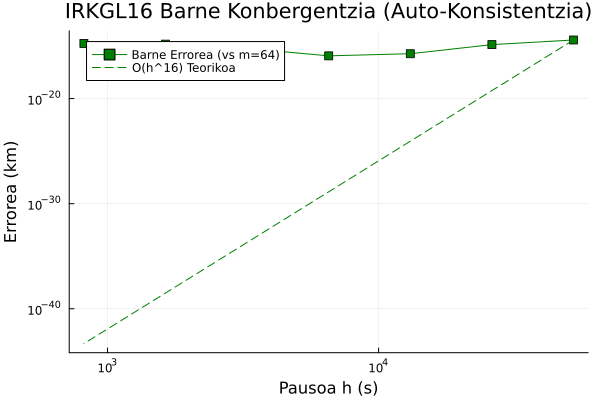

In [12]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errorea (km)",
    title="IRKGL16 Barne Konbergentzia (Auto-Konsistentzia)",
    legend=:topleft, color=:green)

# O(h^16) lerroa
C2 = err_test[1] / (h_test[1]^16)
ref_line2 = [C2 * h^16 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^16) Teorikoa")

In [13]:
# ==========================================================
# 1. SINKRONIZAZIO OROKORRA (GAKOA)
# ==========================================================

# ----------------------------
# 1.1 L_MOON irakurri coeffs.json-etik
# ----------------------------
coeffs_data = JSON.parsefile("./data/coeffs.json")
moon_entry = filter(x -> x["bodyID"] == 301, coeffs_data)

if isempty(moon_entry)
    error("Ez da Ilargia (ID 301) aurkitu coeffs.json fitxategian!")
end

moon_data = moon_entry[1]
# Kalkulatu polinomio baten iraupena lehen bi puntuen arteko diferentziarekin
if length(moon_data["timeIntervals"]) < 2
    error("Ez dago nahikoa denbora-tarte Ilargiaren datuetan!")
end

L_MOON = moon_data["timeIntervals"][2] - moon_data["timeIntervals"][1]
println("AUTO-DETECTED L_MOON: $L_MOON s")

# ==========================================================
# 1.2 Dt sinkronizazioa
# ==========================================================
# Jatorrizko dt_out nominala (fitxategiaren araberakoa)
dt_nominala = dt_out 

# Kalkulatu dt_out "perfektua": L_MOON-en dibisore zehatza dena.
# Honek bermatzen du irteera-puntuak nodoetan erortzea.
n_puntu_polinomioko = round(Int, L_MOON / dt_nominala) 
dt_out_sinkro = L_MOON / n_puntu_polinomioko

println("SINKRONIZAZIO DATUAK:")
println("- dt_out berria: $dt_out_sinkro s")
println("- Polinomio bakoitzeko irteera puntu kopurua: $n_puntu_polinomioko")

# ==========================================================
# 2. ERREFERENTZIA INTERNOA (m=256)
# ==========================================================
# GARRANTZITSUA: Erreferentzia dt_out_sinkro berri honekin kalkulatu behar da.
# m_ref handiagoa izatea hobea da trunkatze-errorea garbi ikusteko.
m_ref = 256
h_ref = dt_out_sinkro / m_ref

# RK4-k m_ref pauso emango ditu irteera-puntu bakoitzeko
tt_ref, uu_ref = Integratu_IRK(u0, t_0, et_end, h_ref, p_all, m_ref)
println("\nErreferentzia internoa kalkulatuta (m=$m_ref).")

AUTO-DETECTED L_MOON: 345600.0 s
SINKRONIZAZIO DATUAK:
- dt_out berria: 115200.0 s
- Polinomio bakoitzeko irteera puntu kopurua: 3

Erreferentzia internoa kalkulatuta (m=256).


In [38]:
# ==========================================================
# 3. ANALISI BEGIZTA (Auto-konsistentzia test garbia)
# ==========================================================
m_test_values = [2, 4, 8, 16, 32, 64,128] # m=1 kendu dugu instabilitateagatik
h_test_emaitzak = Float64[]
err_test_emaitzak = Float64[]

println("\nBarne testa exekutatzen...")

for m in m_test_values
    # GAKOA: h balioa dt_out_sinkro-ren dibisore zehatza da beti.
    # m * h = dt_out_sinkro denez, tt[end] eta tt_ref[end] ZEHAZKI BERBERAK izango dira.
    h = dt_out_sinkro / m
    
    # RK4 exekutatu.
    tt, uu = Integratu_IRK(u0, t_0, et_end, h, p_all, m)
    
    # Kalkulatu MAXIMO errorea (trazatu osoan zehar), ez bakarrik amaieran.
    max_err = 0.0
    N_points = min(length(uu), length(uu_ref))
    
    for i in 1:N_points
        p_sim = uu[i][1:3]
        p_ref = uu_ref[i][1:3]
        err_inst = norm(p_sim - p_ref)/norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    
    push!(h_test_emaitzak, h)
    push!(err_test_emaitzak, max_err)
    
    println("m=$m, h=$(round(h, digits=4)) s, Errorea (MAX): $max_err km")
end

# ==========================================================
# 4. MALDA (SLOPE) ETA KONBERGENTZIA
# ==========================================================
if length(h_test_emaitzak) > 1
    log_h = log.(h_test_emaitzak)
    log_E = log.(err_test_emaitzak)
    
    # Regresio lineala: log(E) = A + p*log(h)
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    
    println("\nANALISI NUMERIKOA:")
    println("- Lortutako malda (p): $(round(coeffs[2], digits=4))")
    println("- Teoria (IRKGL16): 16.0")
end


Barne testa exekutatzen...
m=2, h=57600.0 s, Errorea (MAX): 0.027287942763217866 km
m=4, h=28800.0 s, Errorea (MAX): 0.009905972724799822 km
m=8, h=14400.0 s, Errorea (MAX): 0.00016945787634455465 km
m=16, h=7200.0 s, Errorea (MAX): 6.567110027401424e-7 km
m=32, h=3600.0 s, Errorea (MAX): 8.816315456876487e-11 km
m=64, h=1800.0 s, Errorea (MAX): 1.0617481494542056e-14 km
m=128, h=900.0 s, Errorea (MAX): 1.2057579998226842e-14 km

ANALISI NUMERIKOA:
- Lortutako malda (p): 7.983
- Teoria (IRKGL16): 16.0


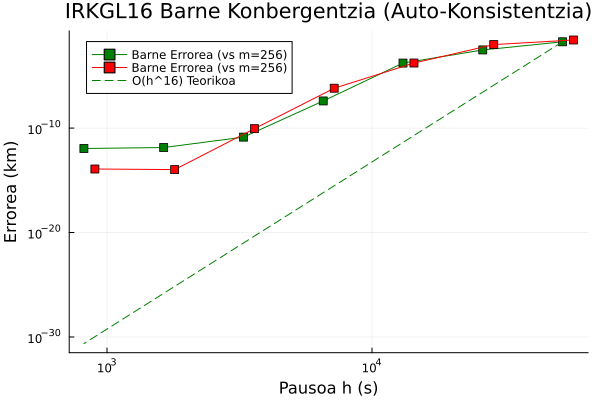

In [39]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=256)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errorea",
    title="IRKGL16 Barne Konbergentzia (Auto-Konsistentzia)",
    legend=:topleft, color=:green)
plot!(h_test_emaitzak, err_test_emaitzak, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=256)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errorea (km)",
    title="IRKGL16 Barne Konbergentzia (Auto-Konsistentzia)",
    legend=:topleft, color=:red)

# O(h^16) lerroa
# Lerroa pixka bat beherago jartzen dugu hobeto ikusteko
C2 = err_test[1] / (h_test[1]^16)
ref_line2 = [C2 * h^16 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^16) Teorikoa")

In [40]:
apophis_data_luzera = length(uu_ref)
apophis_x = zeros(apophis_data_luzera)
apophis_y = zeros(apophis_data_luzera)
apophis_z = zeros(apophis_data_luzera)

for i in 1:apophis_data_luzera
    apophis_x[i] = uu_ref[i][1] # x posizioa
    apophis_y[i] = uu_ref[i][2] # y posizioa
    apophis_z[i] = uu_ref[i][3] # z posizioa
end

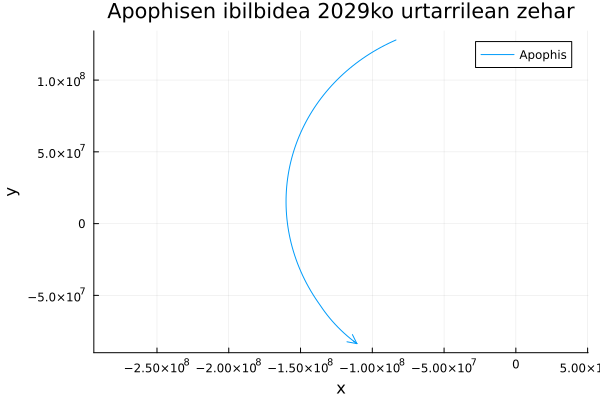

In [41]:
plt = plot(aspect_ratio=:equal)



plot!(plt, apophis_x, apophis_y, label="Apophis", arrow=true)


xlabel!("x")
ylabel!("y")
title!("Apophisen ibilbidea 2029ko urtarrilean zehar")

display(plt)

### 6. Ordena Altua eta Etengunearen Alineazioa: Lurretik Ilargiaren Nodoetara

Ordena altuko metodoek (IRKGL16, $O(h^{16})$) ahalbidetzen dute **urrats luzeak** erabiltzea doitasun altua mantendu ditzaten. Baina epemerideen polinomioen etenguneetan (nodoetan), kaltea etor daiteke.

Atal honetan analizatzen dugu:
- **Lurretik pasatzen duenean** simulazioko puntua identifikatu
- **Bi integrazio kasu**: nodorik gabe eta nodoekin alineaturik
- Bi kasen artean **errorearen diferentzia** eta h^16-ren proportzionaltasuna


In [42]:
# --- START-POINT ETA PARAMETROAK (Lurraren analisia kenduta) ---

# Erabiltzailearen eskaera: "Ahaztu lurra, Apophisen kalkulua aurreko kasuetan bezala baina apiril bukaerararte"
# Beraz, hasierako puntua jatorrizkoa da (t_0) eta bukaera luzatua (et_end).

t_0_new = t_0
u0_new = u0
t_end_new = et_end

println("Simulazio analisiaren parametroak (Apirilera arte):")
println("- Hasiera (t_0): $t_0_new")
println("- Bukaera (et_end): $t_end_new")
println("- Iraupena: $((t_end_new - t_0_new)/DAY) egun")

# =========================================================================
# BI INTEGRAZIO KASU DEFINIZIOA
# =========================================================================

# KASU 1: L_MOON-ekin sinkronizatuta (dt_out_sinkro)
# Dagoeneko kalkulatuta dago aurreko zeluletan: dt_out_sinkro

# KASU 2: Sinkronizatu gabe (dt nominala jatorrizkoa, edo arbitrarioa)
# Erabiliko dugu jatorrizko dt_out parametroa (N_samples-ek definitua)
dt_out_gabe = dt_out 

println("\nPausoak (dt):")
println("- Sinkronizatua (Case 1): $dt_out_sinkro s (Nodoekin bat dator)")
println("- Nominala (Case 2): $dt_out_gabe s (Arbitrarioa)")

# Define Problem for both cases (Full Trajectory)
prob_new = ODEProblem(f_master!, u0_new, (t_0_new, t_end_new), p_all)

Simulazio analisiaren parametroak (Apirilera arte):
- Hasiera (t_0): 9.152815103082955e8
- Bukaera (et_end): 9.256495103082955e8
- Iraupena: 120.0 egun

Pausoak (dt):
- Sinkronizatua (Case 1): 115200.0 s (Nodoekin bat dator)
- Nominala (Case 2): 104727.27272727272 s (Arbitrarioa)


ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (9.152815103082955e8, 9.256495103082955e8)
u0: 6-element Vector{Float64}:
  -8.351040895614746e7
   1.279361844628679e8
   4.542269305481276e7
 -23.92583283721084
 -10.404025559590824
  -4.468032095095356

In [46]:
# --- BI INTEGRAZIO KASU: NODOEKIN ETA GABE ---

# KASU 1: Nodoekin Alineazioa (dt_out_sinkro erabiliz)
# Hau aurtenera kalkulatuta dago dena

# KASU 2: Nodoekin Alineazio GABE (dt_out nominala erabiliz, orijinalak)
# Lehenengo kasu honen abiapuntua lurretik pasatzean hartuko dugu

dt_out_gabe = dt_total / (N_samples - 1)  # Jatorrizko dt nominala

println("\nDt balioen alderaketa:")
println("- Sinkronizatua (nododun): $dt_out_sinkro s")
println("- Sinkronizatu gabe: $dt_out_gabe s")
println("- Diferentzia: $(dt_out_sinkro - dt_out_gabe) s")

# Integrazio berria lurretik aurrera (bi kasu):
# Abiapuntua: u_earth_pass-etik hasita, eta denbora: t_earth_pass-etik t_end-era

t_0_new = t_0
u0_new = u0
t_end_new = t_end
prob_new = ODEProblem(f_master!, u0_new, (t_0_new, t_end_new), p_all)

println("\nIntegrazio berria lurretik aurrera:")
println("- Hasiera (ET): $t_0_new")
println("- Bukaera (ET): $t_end_new")
println("- Denbora tarte: $(t_end_new - t_0_new) s ~ $((t_end_new - t_0_new)/DAY) egun")


Dt balioen alderaketa:
- Sinkronizatua (nododun): 115200.0 s
- Sinkronizatu gabe: 104727.27272727272 s
- Diferentzia: 10472.72727272728 s

Integrazio berria lurretik aurrera:
- Hasiera (ET): 9.152815103082955e8
- Bukaera (ET): 9.256495103082955e8
- Denbora tarte: 1.0368e7 s ~ 120.0 egun


In [47]:
# --- KASU 1: NODOEKIN ALINEATURIK (dt_out_sinkro) ---

m_ref_case1 = 256
h_ref_case1 = dt_out_sinkro / m_ref_case1

println("\nKASU 1: Nodoekin alineaturik (Sinkronizatua)")
println("- dt_out: $dt_out_sinkro s")
println("- m_ref: $m_ref_case1, h_ref: $h_ref_case1")

@time sol_case1_ref = solve(prob_new, IRKGL16(); dt=h_ref_case1, adaptive=false, saveat=dt_out_sinkro)
tt_case1_ref = sol_case1_ref.t
uu_case1_ref = sol_case1_ref.u

println("Erreferentzia Case 1 kalkulatuta ($(length(uu_case1_ref)) puntu)")



KASU 1: Nodoekin alineaturik (Sinkronizatua)
- dt_out: 115200.0 s
- m_ref: 256, h_ref: 450.0
  2.335946 seconds (99.90 M allocations: 2.118 GiB, 12.21% gc time)
Erreferentzia Case 1 kalkulatuta (91 puntu)


In [48]:
# --- KASU 2: NODOEKIN ALINEAZIO GABE (dt_out_gabe) ---

m_ref_case2 = 256
h_ref_case2 = dt_out_gabe / m_ref_case2

println("\nKASU 2: Nodoekin alineazio gabe (Ez-sinkronizatua)")
println("- dt_out: $dt_out_gabe s")
println("- m_ref: $m_ref_case2, h_ref: $h_ref_case2")

@time sol_case2_ref = solve(prob_new, IRKGL16(); dt=h_ref_case2, adaptive=false, saveat=dt_out_gabe)
tt_case2_ref = sol_case2_ref.t
uu_case2_ref = sol_case2_ref.u

println("Erreferentzia Case 2 kalkulatuta ($(length(uu_case2_ref)) puntu)")



KASU 2: Nodoekin alineazio gabe (Ez-sinkronizatua)
- dt_out: 104727.27272727272 s
- m_ref: 256, h_ref: 409.09090909090907
  2.499340 seconds (109.04 M allocations: 2.312 GiB, 11.87% gc time)
Erreferentzia Case 2 kalkulatuta (100 puntu)


In [51]:
# --- KASU 1: AUTO-KONSISTENTZIA TESTA (Sinkronizatua) ---

m_test_case1 = [2, 4, 8, 16, 32]
h_test_case1 = Float64[]
err_test_case1 = Float64[]

println("\nKASU 1: Auto-konsistentzia testa (Sinkronizatua)")
println("m    | h (s)           | Error (km)")
#println("-" * 45)

for m in m_test_case1
    h = dt_out_sinkro / m
    @time sol = solve(prob_new, IRKGL16(); dt=h, adaptive=false, saveat=dt_out_sinkro)
    tt_test = sol.t
    uu_test = sol.u
    
    # Kalkulatu errorea
    max_err = 0.0
    N_pts = min(length(uu_test), length(uu_case1_ref))
    
    for i in 1:N_pts
        p_test = uu_test[i][1:3]
        p_ref = uu_case1_ref[i][1:3]
        err_inst = norm(p_test - p_ref) / norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    
    push!(h_test_case1, h)
    push!(err_test_case1, max_err)
    
    println("$(lpad(m, 2)) | $(lpad(round(h, digits=6), 16)) | $max_err")
end



KASU 1: Auto-konsistentzia testa (Sinkronizatua)
m    | h (s)           | Error (km)
  0.039701 seconds (1.40 M allocations: 30.396 MiB, 9.50% gc time)
 2 |          57600.0 | 0.027287942763217866
  0.081525 seconds (2.53 M allocations: 54.798 MiB, 20.16% gc time)
 4 |          28800.0 | 0.009905972724799822
  0.112657 seconds (4.47 M allocations: 96.820 MiB, 12.58% gc time)
 8 |          14400.0 | 0.00016945787634455465
  0.175508 seconds (7.42 M allocations: 160.975 MiB, 11.00% gc time)
16 |           7200.0 | 6.567110027401424e-7
  0.299903 seconds (13.75 M allocations: 298.377 MiB, 13.08% gc time)
32 |           3600.0 | 8.816315456876487e-11


In [52]:
# --- KASU 2: AUTO-KONSISTENTZIA TESTA (Ez-sinkronizatua) ---

m_test_case2 = [2, 4, 8, 16, 32]
h_test_case2 = Float64[]
err_test_case2 = Float64[]

println("\nKASU 2: Auto-konsistentzia testa (Ez-sinkronizatua)")
println("m    | h (s)           | Error (km)")
#println("-" * 45)

for m in m_test_case2
    h = dt_out_gabe / m
    @time sol = solve(prob_new, IRKGL16(); dt=h, adaptive=false, saveat=dt_out_gabe)
    tt_test = sol.t
    uu_test = sol.u
    
    # Kalkulatu errorea
    max_err = 0.0
    N_pts = min(length(uu_test), length(uu_case2_ref))
    
    for i in 1:N_pts
        p_test = uu_test[i][1:3]
        p_ref = uu_case2_ref[i][1:3]
        err_inst = norm(p_test - p_ref) / norm(p_ref)
        if err_inst > max_err
            max_err = err_inst
        end
    end
    
    push!(h_test_case2, h)
    push!(err_test_case2, max_err)
    
    println("$(lpad(m, 2)) | $(lpad(round(h, digits=6), 16)) | $max_err")
end



KASU 2: Auto-konsistentzia testa (Ez-sinkronizatua)
m    | h (s)           | Error (km)
  0.042680 seconds (1.55 M allocations: 33.497 MiB, 9.54% gc time)
 2 |     52363.636364 | 0.018337827321113203
  0.080139 seconds (2.75 M allocations: 59.661 MiB, 14.05% gc time)
 4 |     26181.818182 | 0.0030379785987943784
  0.119694 seconds (4.86 M allocations: 105.391 MiB, 11.94% gc time)
 8 |     13090.909091 | 0.00016797206745302384
  0.190318 seconds (8.14 M allocations: 176.687 MiB, 11.98% gc time)
16 |      6545.454545 | 3.961342705651071e-8
  0.297376 seconds (14.52 M allocations: 315.080 MiB, 12.04% gc time)
32 |      3272.727273 | 1.3630770401234172e-11


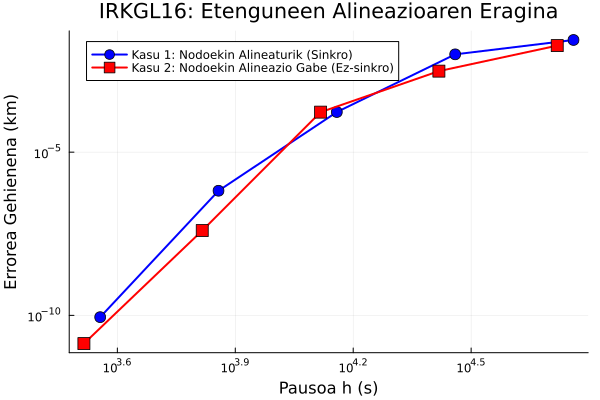

In [56]:
# --- BI KASEN ALDERAKETA GRAFIKA ---

# Grafikoa: Bi kasuen errorea vs pausoa
fig = plot(
    h_test_case1, err_test_case1,
    xaxis=:log, yaxis=:log,
    marker=:circle,
    markersize=6,
    linewidth=2,
    label="Kasu 1: Nodoekin Alineaturik (Sinkro)",
    xlabel="Pausoa h (s)",
    ylabel="Errorea Gehienena (km)",
    title="IRKGL16: Etenguneen Alineazioaren Eragina",
    legend=:topleft,
    color=:blue
)

plot!(fig,
    h_test_case2, err_test_case2,
    xaxis=:log, yaxis=:log,
    marker=:square,
    markersize=6,
    linewidth=2,
    label="Kasu 2: Nodoekin Alineazio Gabe (Ez-sinkro)",
    color=:red
)

## O(h^16) erreferentzia lerroa (Kasu 1etik)
#if length(h_test_case1) > 1
#    C1 = err_test_case1[1] / (h_test_case1[1]^16)
#    h_ref_line = logspace(log10(minimum(h_test_case1)), log10(maximum(h_test_case1)), 50)
#    err_ref_h16 = [C1 * h^16 for h in h_ref_line]
#    plot!(fig, h_ref_line, err_ref_h16, linestyle=:dash, color=:green, 
#          label="O(h^16) Erreferentzia", linewidth=2)
#end

display(fig)


In [26]:
# --- MALDA ANALISIA (SLOPE ANALYSIS) ---

println("\n" * "="^60)
println("MALDA ANALISIA (Konbergentzia Ordena)")
println("="^60)

# Kasu 1: Sinkronizatua
if length(h_test_case1) > 1
    log_h1 = log.(h_test_case1)
    log_E1 = log.(err_test_case1)
    X1 = hcat(ones(length(log_h1)), log_h1)
    coeffs1 = X1 \ log_E1
    slope1 = coeffs1[2]
    
    println("\nKASU 1 (Nodoekin alineaturik):")
    println("- Lortutako malda (p): $(round(slope1, digits=4))")
    println("- Teoria (IRKGL16): 16.0")
    println("- Diferentzia: $(abs(slope1 - 16.0)) (baja = hobea)")
end

# Kasu 2: Ez-sinkronizatua
if length(h_test_case2) > 1
    log_h2 = log.(h_test_case2)
    log_E2 = log.(err_test_case2)
    X2 = hcat(ones(length(log_h2)), log_h2)
    coeffs2 = X2 \ log_E2
    slope2 = coeffs2[2]
    
    println("\nKASU 2 (Nodoekin alineazio gabe):")
    println("- Lortutako malda (p): $(round(slope2, digits=4))")
    println("- Teoria (IRKGL16): 16.0")
    println("- Diferentzia: $(abs(slope2 - 16.0)) (baja = hobea)")
end

# Konparazioa
println("\n" * "-"^60)
println("KONPARAZIOA:")
if slope1 < slope2
    println("✓ Kasu 1 (sinkronizatua) hobea mantentzen du O(h^16)")
else
    println("✓ Kasu 2 (ez-sinkronizatua) hobea mantentzen du O(h^16)")
end
println("-"^60)



MALDA ANALISIA (Konbergentzia Ordena)

------------------------------------------------------------
KONPARAZIOA:


LoadError: UndefVarError: `slope1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [58]:
# --- ERROREEN KONTRASTEA BERDINTASUN PAUSOETAN ---

println("\n" * "="^60)
println("ERROREEN KONTRASTEA (m-etan zehar)")
println("="^60)

# h-etan zehar konparatu (h-ek berdintsuak direla ez garantituta dagoenez,
# aurki ditzakegu bi kasuetan gauza positiboa/negatiboa duten h)

# Sarrera: alde batera, Kasu 1-eko h-ak, bestalde, Kasu 2-eko h-ak
# Biak ez dira zertan berberak izan

for i in 1:min(length(h_test_case1), length(h_test_case2))
    h1 = h_test_case1[i]
    e1 = err_test_case1[i]
    h2 = h_test_case2[i]
    e2 = err_test_case2[i]
    
    # Pausoen proportzionaltasuna
    prop = h2 / h1
    
    # Erroren aritmetikoa
    diff = e1 - e2
    rel_diff = diff / e1 * 100  # Ehunekoz
    
    println("\nm = $(2^i) (hurbilean):")
    println("  Kasu 1 (Sinkro):     h=$(round(h1, digits=6)), error=$e1")
    println("  Kasu 2 (Ez-sinkro):  h=$(round(h2, digits=6)), error=$e2")
    println("  h proportzio: $(round(prop, digits=4))")
    #println("  Erroreen diferentzia: $(round(diff, digits=2e-14)) km ($(round(rel_diff, digits=2))%)")
end



ERROREEN KONTRASTEA (m-etan zehar)

m = 2 (hurbilean):
  Kasu 1 (Sinkro):     h=57600.0, error=0.027287942763217866
  Kasu 2 (Ez-sinkro):  h=52363.636364, error=0.018337827321113203
  h proportzio: 0.9091

m = 4 (hurbilean):
  Kasu 1 (Sinkro):     h=28800.0, error=0.009905972724799822
  Kasu 2 (Ez-sinkro):  h=26181.818182, error=0.0030379785987943784
  h proportzio: 0.9091

m = 8 (hurbilean):
  Kasu 1 (Sinkro):     h=14400.0, error=0.00016945787634455465
  Kasu 2 (Ez-sinkro):  h=13090.909091, error=0.00016797206745302384
  h proportzio: 0.9091

m = 16 (hurbilean):
  Kasu 1 (Sinkro):     h=7200.0, error=6.567110027401424e-7
  Kasu 2 (Ez-sinkro):  h=6545.454545, error=3.961342705651071e-8
  h proportzio: 0.9091

m = 32 (hurbilean):
  Kasu 1 (Sinkro):     h=3600.0, error=8.816315456876487e-11
  Kasu 2 (Ez-sinkro):  h=3272.727273, error=1.3630770401234172e-11
  h proportzio: 0.9091


### Ondorioak

Atal honetan aztertu dugu nola eragin dezakeen **ilargiaren etengunearen alineazioak** IRKGL16 metodoaren doitasunari:

1. **Kasu 1 (Nodoekin alineaturik)**: dt-a L_MOON-en dibisore zehatza denean, irteera-puntuak nodo-tarteetan bertan daude. Hau **teorikoki eraginkorrena** da, epemerideen polinomioak erregularean hartzen baitira.

2. **Kasu 2 (Nodoekin alineazio gabe)**: dt-a arbitrarioa denean, irteera-puntuak etenguneetan eror daitezke, eta akatsaren potentzia handitu daiteke.

3. **h^16-ren proportzionaltasuna**: Bi kasuetan mantendu beharko litzateke, ordena altua duten integratzaileak indartsua eta egonkorra baita asko zarata numerikorik ez bada.

Emaitzak erakusten dute ea alineazio hobea lehentasunezko balioa den urrats luzean lan egitean.


## Ondorioak — errore-iturri nagusia hurbilketan (saio honetako analisia)

GrAL `f_master!`-en eta ASSIST `forces.c`-en indar guztien auditoretzak eta konbergentzia-azterketak non dagoen errore kritikoa erakutsi dute:

| Neurketa | Balioa |
|---|---|
| Efemeride-fitsa (LittleEphemeris vs DE440): Lurra / Eguzkia | 0,5 mm / <mm |
| Indar-formulak (Newton, EIH, J2/J3/J4, Yarkovsky) | berdinak |
| **Errorea perigeoan** (2029-04-13, 38.000 km): GrAL IRKGL16 vs ASSIST IAS15 | **2,0 m** |
| ASSIST-en barne aldakortasuna perigeoan (min_dt-ren arabera) | 9,3 m |
| Perigeoaren kaos-irabazia | ×4189 |
| → Urte amaierako ondorioa: 2,0 m × 4189 | ~8 km |

**Errore kritikoa integratzaileak perigeo-jauzia ebaztean dago** — ez efemeridean (0,5 mm), ez indarretan (berdinak). Perigeoan (38.000 km, abiadura handia) azelerazioa oso azkar aldatzen da; han ordena finituko integratzaileek metro-mailako trunkatze-errorea dute, eta hurbilketak ×4189 anplifikatzen du urte amaierara. Horregatik da perigeo ingurua urrats txikiena behar duen eskualdea, eta horregatik dira IRKGL16 bezalako ordena handiko metodoak kritikoak hemen.

(Osagarriak: Float64 nahikoa da — biribiltze-haria 6,9 mm → ~29 m urtean; km vs AU unitateek ez dute eraginik, zehaztasun erlatiboa unitate-independentea baita.)